In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load the dataset
data = pd.read_csv('combined_cleaned_cardio_data.csv')

In [3]:
# Feature selection
features = ["age", "height", "weight", "ap_hi", "ap_lo", "bmi", "cholesterol", "gluc", "smoke", "alco", "active"]
X = data[features]  # Independent variables
y = data["cardio"]  # Dependent variable (target)

In [4]:
# Handle missing values for numeric columns
X = X.apply(lambda col: col.fillna(col.mean()) if col.dtype in ['float64', 'int64'] else col)

In [5]:
# Encode categorical variables
categorical_features = ["cholesterol", "gluc", "smoke", "alco", "active"]
for feature in categorical_features:
    X[feature] = pd.factorize(X[feature])[0]

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Create and fit the SVM model
svm = SVC(kernel='rbf', gamma='scale', C=1.0)  # RBF kernel with default parameters
svm.fit(X_train, y_train)

SVC()

In [8]:
# Predict on the test set
y_pred = svm.predict(X_test)

In [9]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")

Confusion Matrix:
[[5654 1334]
 [2538 4474]]

Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.81      0.74      6988
        True       0.77      0.64      0.70      7012

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000


Accuracy: 0.72


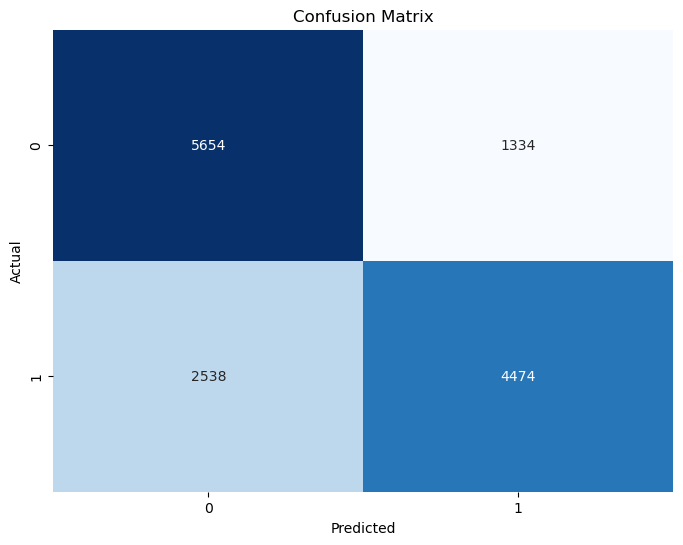

In [10]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sb.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()